In [ ]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from google.colab import drive

drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

Mounted at /content/gdrive


In [ ]:
# read in the merged Station 3 dataset
df_3 = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/merged_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df_3.head()

,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.00,0.158,0.247,0.271,0.332,5.18,6.43,8.50,12.78,0,0.000,-0.547,83.0,0.659,43.71,0.02
2015-01-01 01:00:00,0.00,0.158,0.246,0.271,0.332,5.06,6.33,8.43,12.77,0,0.000,-0.440,81.6,0.670,67.43,0.20
2015-01-01 02:00:00,0.00,0.157,0.246,0.270,0.332,5.00,6.24,8.35,12.73,12288,0.000,-0.175,80.5,0.591,57.45,0.20
2015-01-01 03:00:00,0.00,0.157,0.246,0.270,0.332,4.97,6.16,8.29,12.70,12288,0.000,-0.047,80.8,0.727,77.78,0.17
2015-01-01 04:00:00,0.25,0.157,0.246,0.270,0.332,4.93,6.11,8.22,12.67,12288,0.254,-0.074,88.7,0.321,44.11,0.01


In [ ]:
# statistics of the dataset
df_3.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt_x,58441.0,0.086476,0.977381,0.000,0.000,0.000,0.000,62.740
SWC_5,58441.0,0.168142,0.047569,0.077,0.124,0.168,0.206,0.441
SWC_10,58441.0,0.218932,0.054930,0.119,0.167,0.223,0.264,0.444
SWC_20,58441.0,0.259294,0.063321,0.143,0.197,0.279,0.313,0.424
SWC_50,58441.0,0.289262,0.066878,0.170,0.223,0.307,0.350,0.454
T_5,58441.0,22.386901,8.195860,1.650,15.800,22.860,29.150,43.980
T_10,58441.0,22.395539,7.857962,2.530,15.880,22.780,29.150,41.260
T_20,58441.0,22.528098,7.425235,3.900,16.110,22.780,29.230,38.310
T_50,58441.0,22.638996,6.403203,7.890,16.610,22.610,28.670,34.580
Flag,58441.0,46.591451,651.994111,0.000,0.000,0.000,0.000,13056.000


In [ ]:
# Check if df contains NaN values
df_3.isnull().sum()

Ppt_x             0
SWC_5             0
SWC_10            0
SWC_20            0
SWC_50            0
T_5               0
T_10              0
T_20              0
T_50              0
Flag              0
Ppt_y             0
Tair              0
RH                0
Windspeed         0
Winddirection     0
Srad             76
dtype: int64

In [ ]:
# drop NaN values to prevent issues when training (if NaN values are left in the df, loss cannot compute and training cannot occur)
df_3 = df_3.dropna()
df_3.isnull().sum()

Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

In [ ]:
# drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
df_3 = df_3.drop('Flag', axis = 1)
# rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
df_3 = df_3.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
df_3.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt_soil,58365.0,0.086484,0.977854,0.000,0.000,0.000,0.000,62.740
SWC_5,58365.0,0.168110,0.047565,0.077,0.124,0.168,0.206,0.441
SWC_10,58365.0,0.218868,0.054907,0.119,0.167,0.223,0.264,0.444
SWC_20,58365.0,0.259233,0.063317,0.143,0.197,0.279,0.313,0.424
SWC_50,58365.0,0.289178,0.066865,0.170,0.223,0.307,0.350,0.454
T_5,58365.0,22.381624,8.198733,1.650,15.790,22.850,29.150,43.980
T_10,58365.0,22.392512,7.861503,2.530,15.870,22.780,29.160,41.260
T_20,58365.0,22.526670,7.428645,3.900,16.110,22.780,29.240,38.310
T_50,58365.0,22.637815,6.405699,7.890,16.610,22.610,28.670,34.580
Ppt_met,58365.0,0.086534,0.977872,0.000,0.000,0.000,0.000,62.740


Text(0, 0.5, 'Wind Velocity [m/s]')

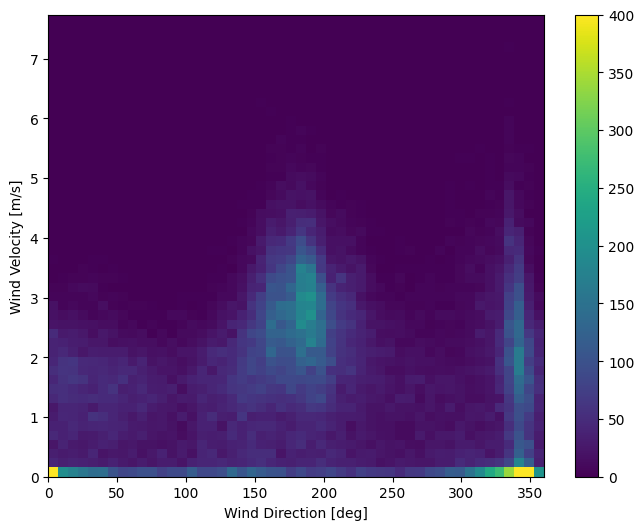

In [ ]:
# distribution of wind data
plt.hist2d(df_3['Winddirection'], df_3['Windspeed'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

In [ ]:
# convert wind velocity and wind direction to a wind vector
wv = df_3.pop('Windspeed')

# Convert to radians.
wd_rad = df_3.pop('Winddirection')*np.pi / 180

# Calculate the wind x and y components.
df_3['Wx'] = wv*np.cos(wd_rad)
df_3['Wy'] = wv*np.sin(wd_rad)

(-6.817641766306396, 7.130611477537051, -5.392009121927736, 4.881035667311084)

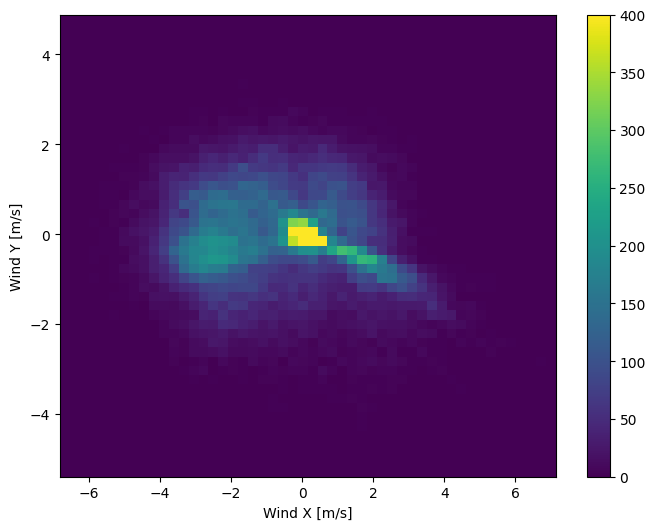

In [ ]:
# The distribution of wind vectors is much simpler for the model to correctly interpret
plt.hist2d(df_3['Wx'], df_3['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [ ]:
# Remove periodicity in time data (remove daily and yearly periodicity)
timestamp_s = (df_3.index).map(pd.Timestamp.timestamp)

day = 24*60*60
year = (365.2425)*day

df_3['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df_3['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df_3['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df_3['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

Text(0.5, 1.0, 'Time of day signal')

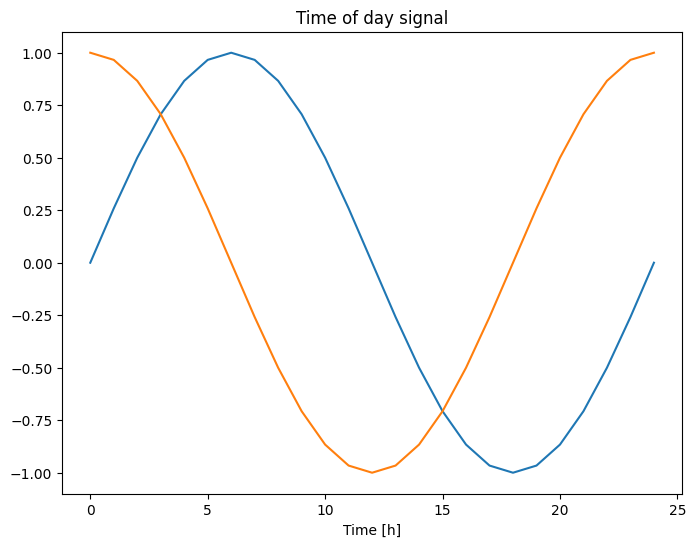

In [ ]:
# plot day sin and cos
plt.plot(np.array(df_3['Day sin'])[:25])
plt.plot(np.array(df_3['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [ ]:
# Split the dataset into 70% (training) 20% (validation) 10% (testing) -> no random shuffling of data
column_indices = {name: i for i, name in enumerate(df_3.columns)}

n = len(df_3)
train_df = df_3[0:int(n*0.7)]
val_df = df_3[int(n*0.7):int(n*0.9)]
test_df = df_3[int(n*0.9):]

num_features = df_3.shape[1]

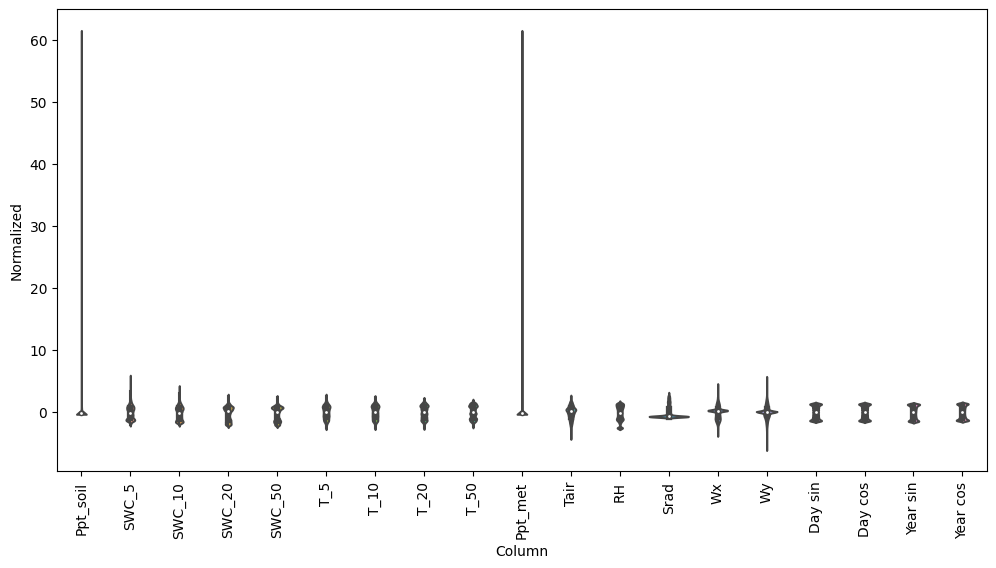

In [ ]:
'''
# normalize the data (using min-max normalization)
train_df = (train_df - train_df.min()) / (train_df.max() - train_df.min())
val_df = (val_df - val_df.min()) / (val_df.max() - val_df.min())
test_df = (test_df - test_df.min()) / (test_df.max() - test_df.min())

# look at distribution of values
df_std = (df_3 - df_3.min()) / (df_3.max() - df_3.min())
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df_3.keys(), rotation=90)
'''
# normalize the data (using mean normalization)
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

# look at the distribution of values
df_std = (df_3 - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df_3.keys(), rotation=90)

In [ ]:
# create window generator class
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [ ]:
# create windowing function
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [ ]:
# simple visualization of the window
def plot(self, model=None, plot_col='SWC_5', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [ ]:
# make dataset from a tf.data.Dataset of (input_window, label_window) pairs 
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [ ]:
# Add properties for accessing train, val, and test data as tf.data.Datasets using the make_dataset method you defined earlier
# Also, add a standard example batch for easy access and plotting
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [ ]:
# configure a WindowGenerator object to produce a single step prediction
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['SWC_5'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['SWC_5']

In [ ]:
# generate a Baseline model
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [ ]:
# instantiate and evaluate this model
baseline = Baseline(label_index=column_indices['SWC_5'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0)

365/365 [==============================] - 2s 4ms/step - loss: 0.0078 - mean_absolute_error: 0.0169


In [ ]:
# generate a wide window of 24 consecutive inputs and labels
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['SWC_5'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['SWC_5']

In [ ]:
# run baseline on the wide_window
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


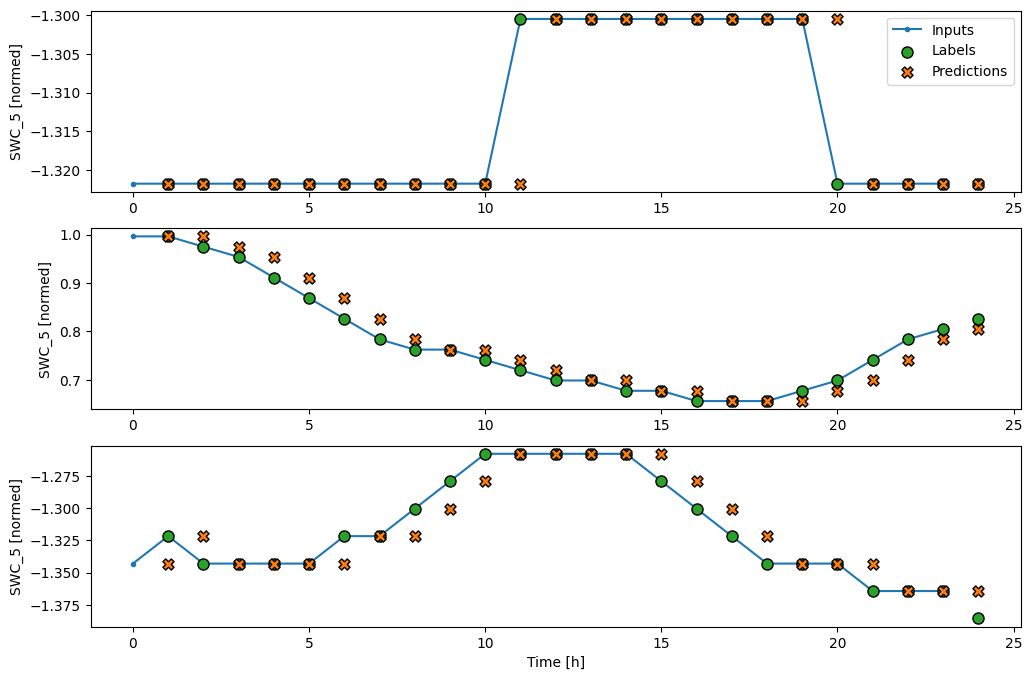

In [ ]:
# plot baseline on the wide window
wide_window.plot(baseline)

In [ ]:
# training procedure
MAX_EPOCHS = 75

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [ ]:
# run the dense model on the single_step_window (1 hour input, 1 hour prediction)
dense = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0)

Epoch 1/75
1277/1277 [==============================] - 16s 10ms/step - loss: 0.0374 - mean_absolute_error: 0.0937 - val_loss: 0.0179 - val_mean_absolute_error: 0.0927
Epoch 2/75
1277/1277 [==============================] - 13s 10ms/step - loss: 0.0141 - mean_absolute_error: 0.0503 - val_loss: 0.0139 - val_mean_absolute_error: 0.0817
Epoch 3/75
1277/1277 [==============================] - 11s 9ms/step - loss: 0.0128 - mean_absolute_error: 0.0467 - val_loss: 0.0118 - val_mean_absolute_error: 0.0701
Epoch 4/75
1277/1277 [==============================] - 11s 8ms/step - loss: 0.0110 - mean_absolute_error: 0.0422 - val_loss: 0.0087 - val_mean_absolute_error: 0.0554
Epoch 5/75
1277/1277 [==============================] - 10s 8ms/step - loss: 0.0108 - mean_absolute_error: 0.0413 - val_loss: 0.0086 - val_mean_absolute_error: 0.0580
Epoch 6/75
1277/1277 [==============================] - 13s 10ms/step - loss: 0.0101 - mean_absolute_error: 0.0394 - val_loss: 0.0096 - val_mean_absolute_error: 0.

In [ ]:
# run multi-step dense model for predicting one step into the future
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    label_columns=['SWC_5'])

conv_window

Total window size: 4
Input indices: [0 1 2]
Label indices: [3]
Label column name(s): ['SWC_5']

Text(0.5, 1.0, 'Given 3 hours of inputs, predict 1 hour into the future.')

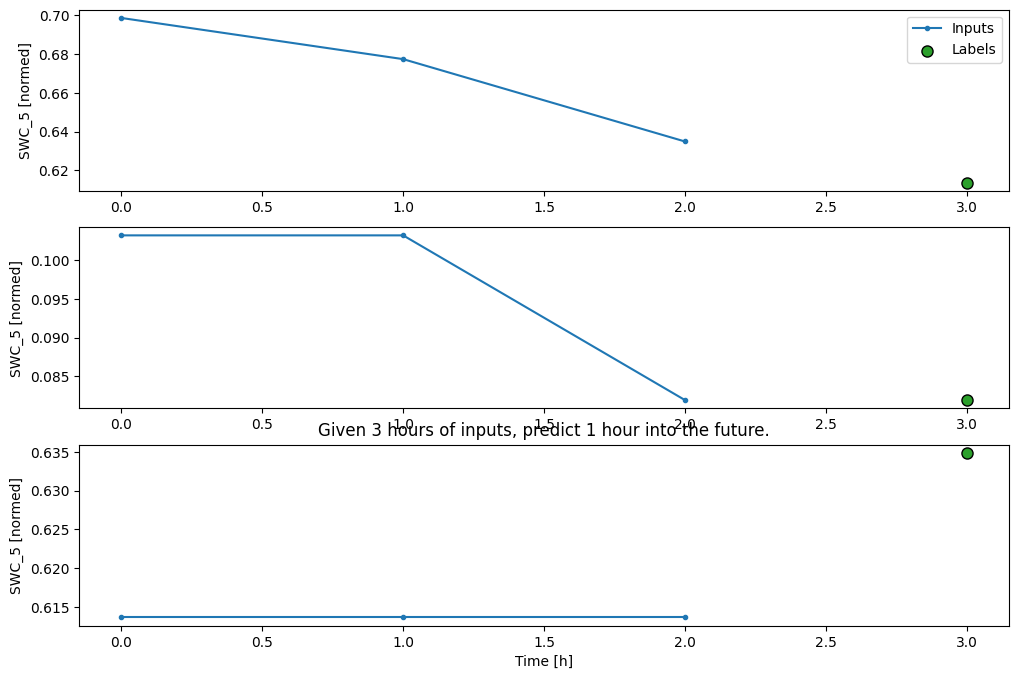

In [ ]:
# plot the window
conv_window.plot()
plt.title("Given 3 hours of inputs, predict 1 hour into the future.")

In [ ]:
# train the dense multi-step model
multi_step_dense = tf.keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf.keras.layers.Reshape([1, -1]),
])

print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

history = compile_and_fit(multi_step_dense, conv_window)
#IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0)

Input shape: (32, 3, 19)
Output shape: (32, 1, 1)
Epoch 1/75
1277/1277 [==============================] - 9s 6ms/step - loss: 0.0439 - mean_absolute_error: 0.1122 - val_loss: 0.0157 - val_mean_absolute_error: 0.0700
Epoch 2/75
1277/1277 [==============================] - 9s 7ms/step - loss: 0.0135 - mean_absolute_error: 0.0542 - val_loss: 0.0115 - val_mean_absolute_error: 0.0605
Epoch 3/75
1277/1277 [==============================] - 9s 7ms/step - loss: 0.0118 - mean_absolute_error: 0.0464 - val_loss: 0.0115 - val_mean_absolute_error: 0.0583
Epoch 4/75
1277/1277 [==============================] - 8s 6ms/step - loss: 0.0104 - mean_absolute_error: 0.0412 - val_loss: 0.0084 - val_mean_absolute_error: 0.0405
Epoch 5/75
1277/1277 [==============================] - 8s 6ms/step - loss: 0.0097 - mean_absolute_error: 0.0402 - val_loss: 0.0086 - val_mean_absolute_error: 0.0448
Epoch 6/75
1277/1277 [==============================] - 9s 7ms/step - loss: 0.0092 - mean_absolute_error: 0.0381 - val_l

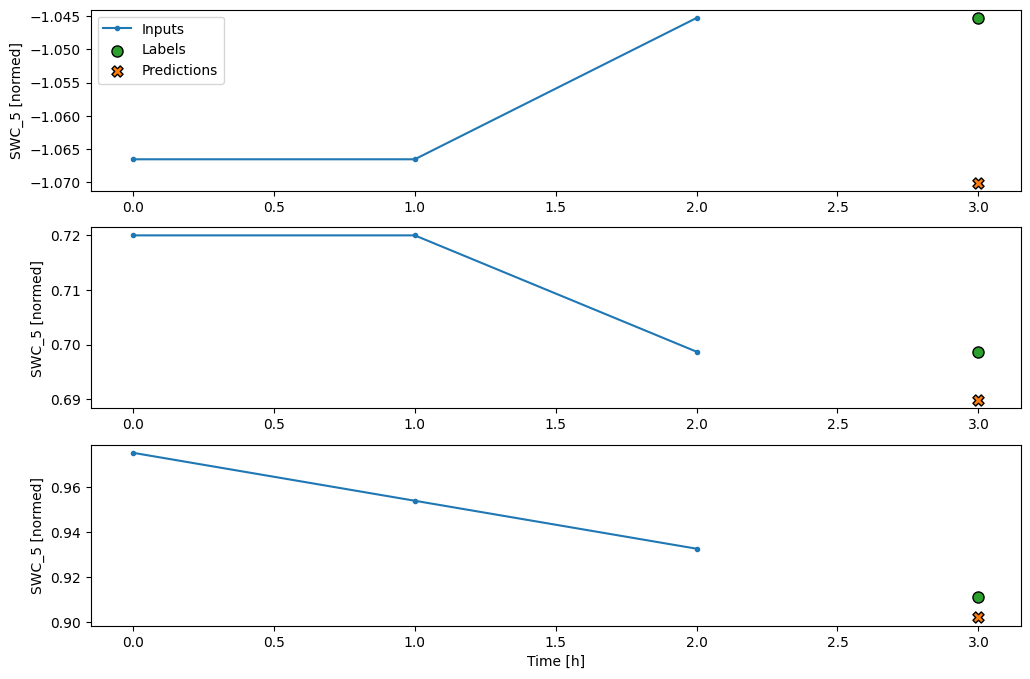

In [ ]:
# plot the results of the multi-step dense model
conv_window.plot(multi_step_dense)

In [ ]:
# create a multi-step input CNN model
conv_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [ ]:
# run model on an example batch to test shape of output
print("Conv model on `conv_window`")
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', conv_model(conv_window.example[0]).shape)

Conv model on `conv_window`
Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [ ]:
# train and evaluate on the conv_window
history = compile_and_fit(conv_model, conv_window)

#IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(conv_window.val)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0)

Epoch 1/75
1277/1277 [==============================] - 11s 8ms/step - loss: 0.0419 - mean_absolute_error: 0.1019 - val_loss: 0.0201 - val_mean_absolute_error: 0.0912
Epoch 2/75
1277/1277 [==============================] - 6s 5ms/step - loss: 0.0126 - mean_absolute_error: 0.0502 - val_loss: 0.0136 - val_mean_absolute_error: 0.0686
Epoch 3/75
1277/1277 [==============================] - 9s 7ms/step - loss: 0.0108 - mean_absolute_error: 0.0439 - val_loss: 0.0128 - val_mean_absolute_error: 0.0675
Epoch 4/75
1277/1277 [==============================] - 8s 6ms/step - loss: 0.0101 - mean_absolute_error: 0.0406 - val_loss: 0.0097 - val_mean_absolute_error: 0.0528
Epoch 5/75
1277/1277 [==============================] - 9s 7ms/step - loss: 0.0096 - mean_absolute_error: 0.0389 - val_loss: 0.0109 - val_mean_absolute_error: 0.0623
Epoch 6/75
1277/1277 [==============================] - 6s 5ms/step - loss: 0.0091 - mean_absolute_error: 0.0374 - val_loss: 0.0119 - val_mean_absolute_error: 0.0687
Epo

In [ ]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

Wide window
Input shape: (32, 24, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 22, 1)


In [ ]:
# build a WindowGenerator to produce wide windows with a few extra input time steps so the label and prediction lengths match (for training and plotting to work)
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    label_columns=['SWC_5'])

wide_conv_window

Total window size: 27
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Label indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Label column name(s): ['SWC_5']

In [ ]:
print("Wide conv window")
print('Input shape:', wide_conv_window.example[0].shape)
print('Labels shape:', wide_conv_window.example[1].shape)
print('Output shape:', conv_model(wide_conv_window.example[0]).shape)

Wide conv window
Input shape: (32, 26, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 24, 1)


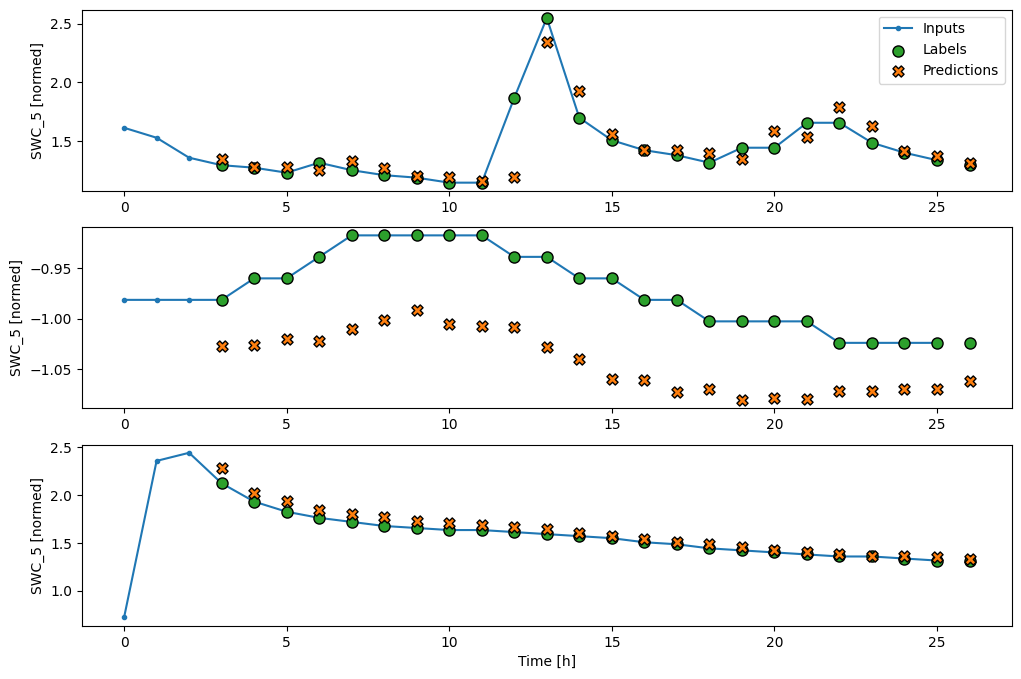

In [ ]:
# plot model's predictions on a wider window (every prediction is based on 3 preceding time steps)
wide_conv_window.plot(conv_model)

In [ ]:
# Create a RNN LSTM model where return_sequences is True (predicts an output for each input along the way)
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


In [ ]:
# train and evaluate the RNN LSTM model
history = compile_and_fit(lstm_model, wide_window)

#IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0)

Epoch 1/75
1276/1276 [==============================] - 29s 20ms/step - loss: 0.0307 - mean_absolute_error: 0.0856 - val_loss: 0.0110 - val_mean_absolute_error: 0.0603
Epoch 2/75
1276/1276 [==============================] - 27s 21ms/step - loss: 0.0070 - mean_absolute_error: 0.0296 - val_loss: 0.0064 - val_mean_absolute_error: 0.0412
Epoch 3/75
1276/1276 [==============================] - 27s 21ms/step - loss: 0.0056 - mean_absolute_error: 0.0249 - val_loss: 0.0058 - val_mean_absolute_error: 0.0336
Epoch 4/75
1276/1276 [==============================] - 25s 19ms/step - loss: 0.0047 - mean_absolute_error: 0.0230 - val_loss: 0.0061 - val_mean_absolute_error: 0.0343
Epoch 5/75
1276/1276 [==============================] - 27s 21ms/step - loss: 0.0042 - mean_absolute_error: 0.0221 - val_loss: 0.0061 - val_mean_absolute_error: 0.0323
Epoch 6/75
1276/1276 [==============================] - 25s 20ms/step - loss: 0.0038 - mean_absolute_error: 0.0214 - val_loss: 0.0065 - val_mean_absolute_error:

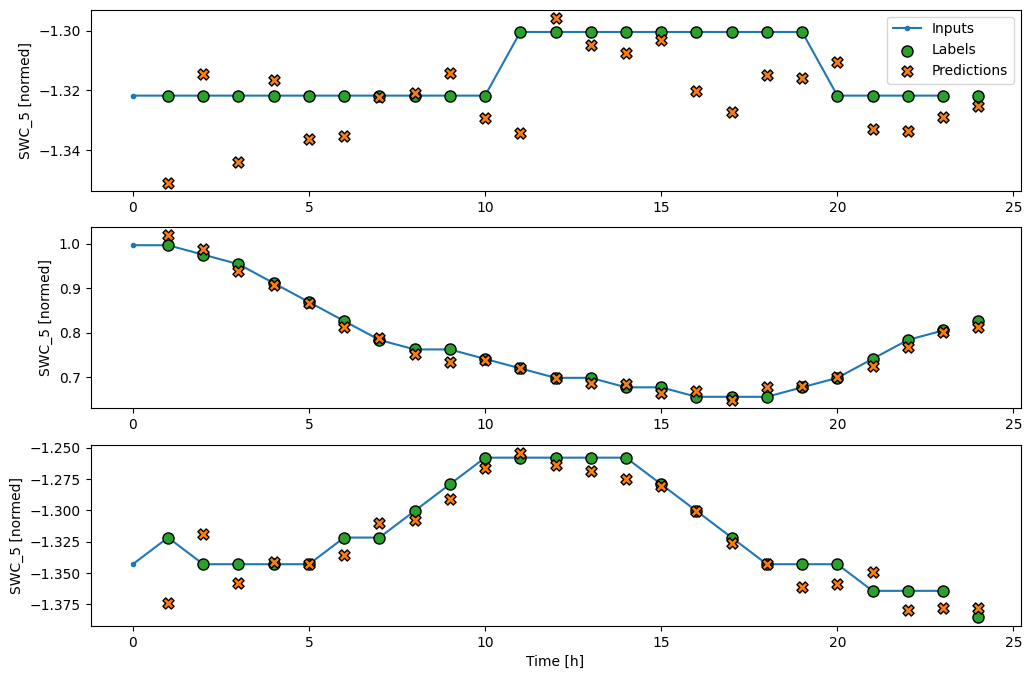

In [ ]:
# plot the results of the model
wide_window.plot(lstm_model)